# Topic 1.2 $\quad$ Descriptive Analysis of a Financial Asset

Before analyzing a portfolio of assets, we will first examine how to analyze a single financial asset. We will cover:

* Downloading and visualizing an asset
* Understanding the limitations of working directly with prices
* The return-risk trade-off
  * Calculating daily returns
  * Difference between arithmetic and logarithmic returns
  * Analyzing returns: do they follow a normal distribution?

In [ ]:
!pip install mplfinance

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import mplfinance as mpf
import plotly.graph_objects as go
import warnings

import yfinance as yf
import missingno as msno

import statsmodels.api as sm

# print(plt.style.available)  # list of available styles
plt.style.use("ggplot")

warnings.simplefilter(action="ignore", category=FutureWarning)

## 1. Downloading and Visualizing an Asset

First, we download Santander OHLC data and visualize it using different tools.

In [ ]:
data_df = yf.download(
    "SAN.MC",
    start="2000-01-01",
    auto_adjust=False,
    multi_level_index=False,
    actions=True
)



data_df

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
2000-01-03,2.594408,9.849401,0.0,9.987881,9.736886,9.953261,0.0,8797337
2000-01-04,2.532854,9.615716,0.0,9.780161,9.529166,9.728231,0.0,8811013
2000-01-05,2.471301,9.382031,0.0,9.555131,9.304136,9.433961,0.0,9333517
2000-01-06,2.471301,9.382031,0.0,9.382031,9.382031,9.382031,0.0,0
2000-01-07,2.580730,9.797471,0.0,9.823436,9.442616,9.451271,0.0,9603132
...,...,...,...,...,...,...,...,...
2026-10-01,11.812000,11.812000,0.0,12.248000,11.812000,12.160000,0.0,34170257
2026-10-02,11.808000,11.808000,0.0,11.942000,11.616000,11.800000,0.0,25160882
2026-10-05,12.342000,12.342000,0.0,12.400000,11.900000,12.030000,0.0,32751254


We display information about the structure of the DataFrame: data types, index, and columns.

In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6872 entries, 2000-01-03 to 2026-10-07
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     6872 non-null   float64
 1   Close         6872 non-null   float64
 2   Dividends     6872 non-null   float64
 3   High          6872 non-null   float64
 4   Low           6872 non-null   float64
 5   Open          6872 non-null   float64
 6   Stock Splits  6872 non-null   float64
 7   Volume        6872 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 483.2 KB


We display descriptive statistics for each numerical column.

In [ ]:
data_df.describe()

,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
count,6872.000000,6872.000000,6872.000000,6872.000000,6872.000000,6872.000000,6872.000000,6.872000e+03
mean,3.447188,6.584773,0.001275,6.664590,6.497093,6.584588,0.000300,7.157194e+07
std,1.743218,2.766319,0.011945,2.788579,2.737942,2.764340,0.017562,6.520229e+07
min,1.219152,1.473533,0.000000,1.502475,1.439417,1.444017,0.000000,0.000000e+00
25%,2.509870,4.301405,0.000000,4.367625,4.240867,4.303575,0.000000,3.251218e+07
50%,3.060814,6.111654,0.000000,6.187225,6.032477,6.118201,0.000000,5.427940e+07
75%,3.943437,8.731900,0.000000,8.834450,8.611735,8.726247,0.000000,8.786741e+07
max,12.952000,12.982515,0.244038,13.181580,12.913275,12.990000,1.043478,9.487686e+08


WHAT IS THE DIFFERENCE BETWEEN THE CLOSING PRICE (`Close`) AND THE ADJUSTED CLOSING PRICE (`Adj Close`)?

To understand the difference, let's examine the effect of stock splits and dividends on share prices:

* A **stock split** divides a company's existing shares into a larger number of shares. For example, if a share is worth €100 and there is a 2-for-1 split, each share will be worth €50. The number of shares doubles and the price per share is divided by two.

* A **dividend** is a payment made by a company to its shareholders. For example, if a share is worth €100 and a €5 dividend is paid, the share price will normally fall by approximately the amount of the dividend.

We will visualize **Banco Santander** data and compare **Close** and **Adj Close**:

* **Close**: closing price without adjustment for dividends and stock splits.

* **Adj Close**: closing price adjusted for dividends and stock splits. This is the price generally used when calculating investment returns.

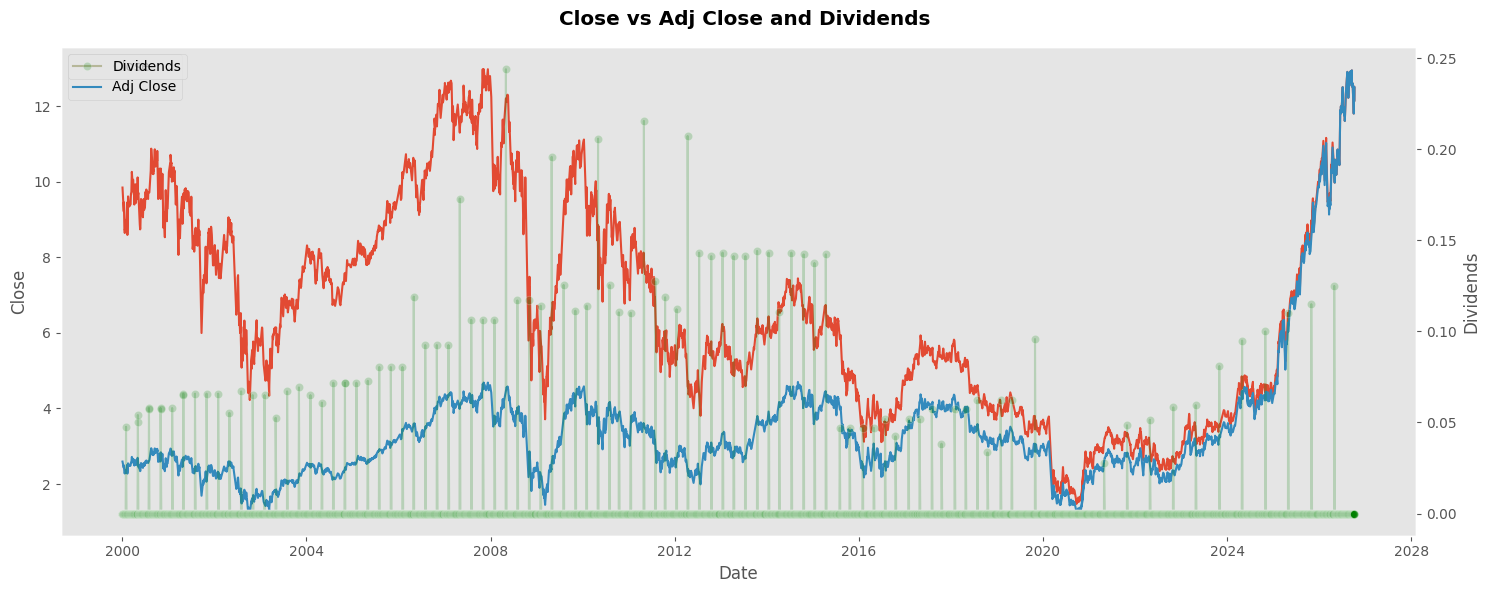

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# First axis
sns.lineplot(data=data_df, x="Date", y="Close", label="Close", ax=ax1)
sns.lineplot(data=data_df, x="Date", y="Adj Close", label="Adj Close", ax=ax1)
ax1.set_xlabel("Date")
ax1.set_ylabel("Close")
ax1.grid(False)

# Second axis
ax2 = ax1.twinx()

sns.lineplot(
    data=data_df,
    x="Date",
    y="Dividends",
    style=True,
    markers=True,
    ax=ax2,
    color="green",
    alpha=0.2,
)
ax2.set_ylabel("Dividends")
ax2.grid(False)
ax2.legend(["Dividends"], loc="upper left")

fig.suptitle("Close vs Adj Close and Dividends")
fig.tight_layout()
plt.show()

A common way to visualize OHLCV data jointly is with a **candlestick chart**.

We can use different libraries for this purpose, for example `mplfinance`.

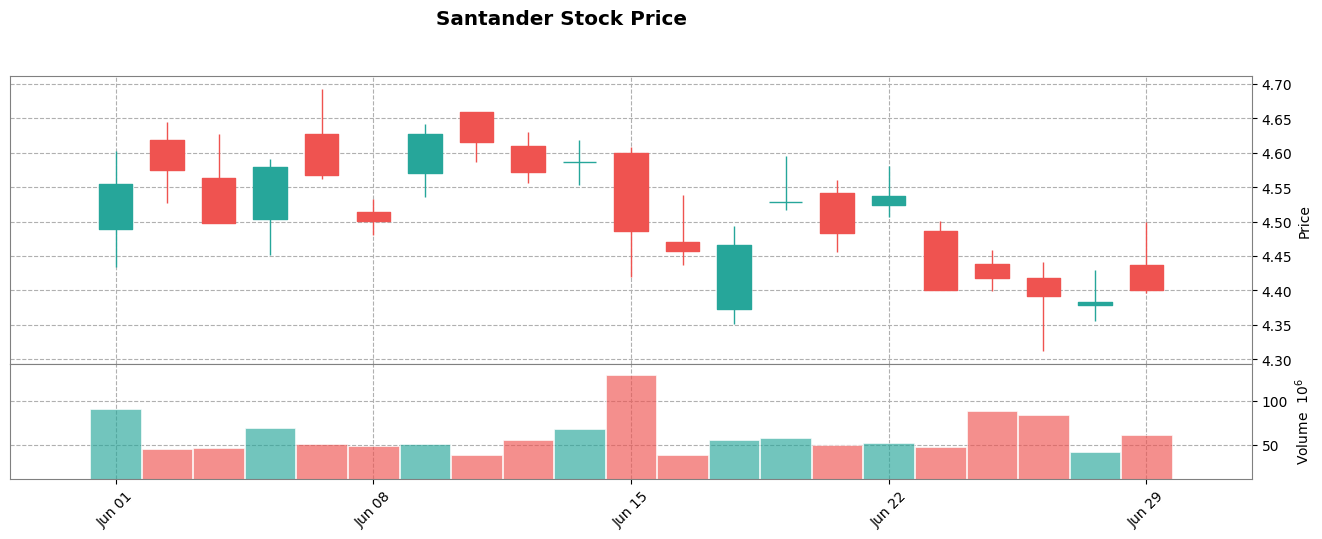

In [ ]:
fig, ax = mpf.plot(
    data_df.loc["2018-06"],
    type="candle",  # 'type' specifies that we want a candlestick chart
    volume=True,  # 'volume' controls whether trading volume is displayed
    style="tradingview",  # 'style' controls the chart appearance
    figratio=(12, 4),
    title=f"Santander Stock Price",
    returnfig=True,
)
# ax[0].axhline(data_df.loc["2018-06-01"]["Open"], color="red", linestyle="--", linewidth=1, alpha=0.5)
# ax[0].axhline(data_df.loc["2018-06-01"]["High"], color="red", linestyle="--", linewidth=1, alpha=0.5)
# ax[0].axhline(data_df.loc["2018-06-01"]["Low"], color="red", linestyle="--", linewidth=1, alpha=0.5)
# ax[0].axhline(data_df.loc["2018-06-01"]["Close"], color="red", linestyle="--", linewidth=1, alpha=0.5)

Alternatively, we can use the `plotly` library:

In [ ]:
fig = go.Figure(
    data=[
        go.Candlestick(
            x=data_df.loc["2018-06"].index,
            open=data_df.loc["2018-06"]["Open"],
            high=data_df.loc["2018-06"]["High"],
            low=data_df.loc["2018-06"]["Low"],
            close=data_df.loc["2018-06"]["Close"],
        )
    ]
)

fig.update_layout(title=f"Santander Candlestick Price Chart", xaxis_tickfont_size=14)
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

Move the mouse over a specific candlestick in the chart. You can inspect the detailed information for that day. You can also zoom, pan, and interact with the chart.

### Quick Practice 1 — Inspecting OHLC Data

Using `data_df`:

1. Display the first 10 observations.
2. Find the highest `High` price in the dataset.
3. Select the `Open`, `High`, `Low`, and `Close` columns for June 2018.

Try to solve the exercise using Pandas indexing and selection methods.

In [ ]:
# Write your code here


## 1.2 Prices vs. Returns

In finance, we usually do not work directly with asset prices. Instead, we work with **returns**. There are two common ways to calculate returns from asset prices:

**Arithmetic returns:**

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

where $P_t$ and $P_{t-1}$ represent closing prices at times $t$ and $t-1$, respectively.

**Logarithmic returns:**

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

where, as before, $P_t$ and $P_{t-1}$ are closing prices at times $t$ and $t-1$, respectively.

In both cases, we measure the change in price between two consecutive points in time, $t$ and $t-1$.

Imagine that you are monitoring the growth of a plant in your garden. Instead of looking only at its absolute height every day, you might be more interested in how much it has grown relative to the previous day. This makes it easier to compare the growth of different plants even if they started at different sizes.

Similarly, in finance we work with returns because we focus on **how assets change relative to their previous value**, rather than comparing their absolute prices. This makes different assets easier to compare and helps us analyze their behavior without being dominated by differences in price scale.

There are several reasons why working with returns is generally more convenient:

* **Data normalization**: Returns remove the absolute price scale, making it easier to compare assets with very different price levels.
* **Statistical analysis**: When working with returns, it is often assumed that **returns are weakly stationary** and have more stable statistical properties than prices.
    * A weakly stationary series has a constant mean and variance, while the covariance between observations depends only on the time lag between them rather than on the calendar date.
* **Risk management**: Risk is usually analyzed in terms of changes in returns rather than absolute price changes.
* **Removal of long-term trends**: Returns largely remove the price-level trend.
* **Convenient calculations**: In many applications, calculations based on returns are simpler than calculations based directly on prices.

For statistical analysis, **logarithmic returns** are also frequently used:
* Log prices are often modeled with distributions that imply log-normal price dynamics.
* When price changes are small, logarithmic and arithmetic returns are very similar.
* $\log(\frac{p_d}{p_{d-1}})=\log(p_d)-\log(p_{d-1})$
* Addition and subtraction are numerically more stable than repeated multiplication and division when working with very small numbers.

Ref.: https://quantivity.wordpress.com/2011/02/21/why-log-returns/

Let's compare arithmetic and logarithmic returns:

In [ ]:
import numpy as np

data_df["log_ret"] = np.log(data_df.loc[:, ["Close"]]).diff()
data_df["pct_ret"] = data_df.loc[:, ["Close"]].pct_change()

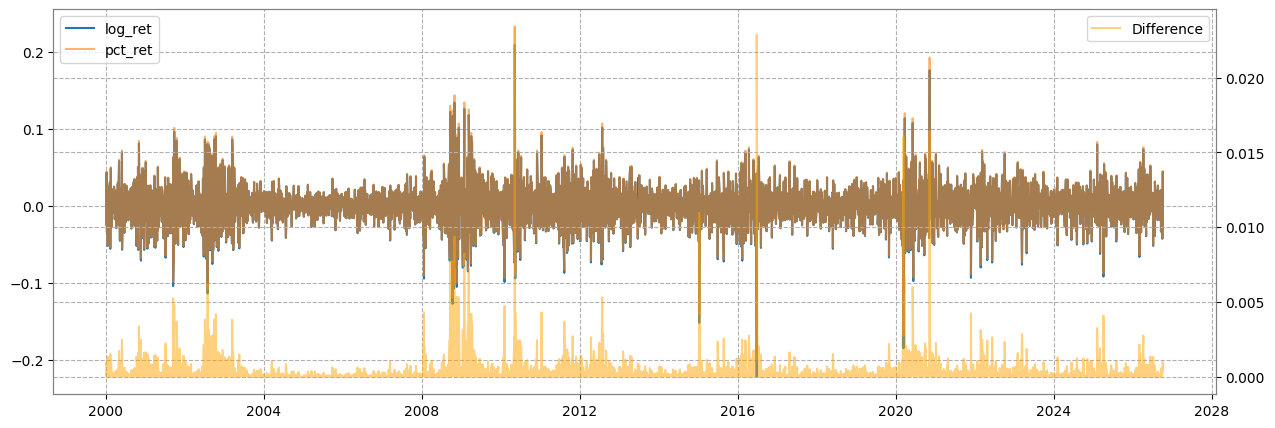

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))

# Plot both return series on the first axis
ax.plot(data_df["log_ret"], label="log_ret")
ax.plot(data_df["pct_ret"], label="pct_ret", alpha=0.6)
plt.legend(loc="upper left")

ax2 = ax.twinx()  # Create a second y-axis
ax2.plot(
    np.abs(data_df["pct_ret"] - data_df["log_ret"]),
    label="Difference",
    color="orange",
    alpha=0.5,
)
plt.legend(loc="upper right")

plt.grid(True)
plt.show()

## 1.3 The Return-Risk Trade-off

Let's plot the returns to examine their evolution over time:

In [ ]:
ret_df = data_df["log_ret"].dropna()

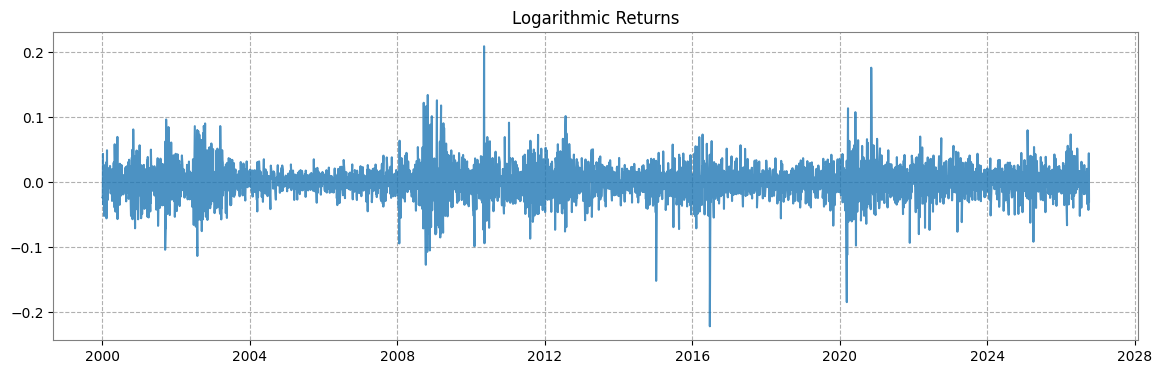

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(ret_df, alpha=0.8)
plt.title("Logarithmic Returns", c="black")
plt.show()

Now let's examine their distribution:

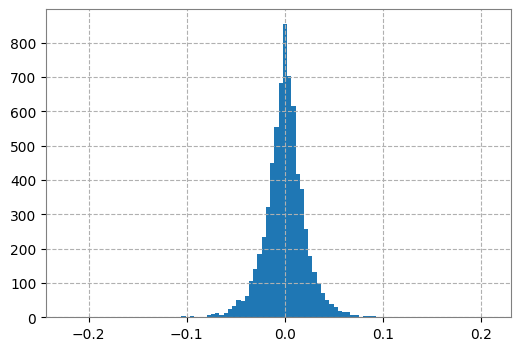

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(ret_df, bins=100)
plt.show()

From the figure, the returns appear approximately normally (Gaussian) distributed. If that were the case, we could characterize them using their mean and standard deviation:

1. Calculate the mean return:

$$\bar{r} = \frac{1}{n} \sum_{i=1}^n r_i$$

2. Calculate the variance of returns:

$$\sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2$$

3. Calculate the standard deviation of returns:

$$\sigma = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2}$$

Return, variance, and standard deviation are usually expressed in **annualized terms**:

- For **daily data**, we assume **252 trading days per year**.
- For **monthly data**, we assume **12 months per year**.

In [ ]:
print(f"Mean return: {ret_df.mean() * 252:.4f}")
print(f"Variance: {ret_df.var() * 252:.4f}")
print(f"Standard deviation: {ret_df.std() * np.sqrt(252):.4f}")

Mean return: 0.0077
Variance: 0.1210
Standard deviation: 0.3479


Since investors are generally risk-averse, we often represent an asset using the **return-risk trade-off**:

- **Return** is measured using the mean return.
- **Risk** is measured using volatility, i.e. the standard deviation of returns.

### Quick Practice 3 — Annualized Return and Risk

Using `ret_df`:

1. Calculate the annualized mean return.
2. Calculate the annualized volatility.
3. Store both values in variables called `annual_return` and `annual_volatility`.
4. Print the results rounded to three decimal places.

In [ ]:
# Write your code here


---

We will now load two groups of assets that will help us analyze different return behaviors.

Reading the files from GitHub (use this option in Colab)

In [ ]:
file_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/refs/heads/Feb-2025/Tema_1_Activos_Intro/data/data_OHLC.xlsx"
data_OHLC_df = pd.read_excel(file_path, header=[0, 1], index_col=0, parse_dates=True)

file_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/refs/heads/Feb-2025/Tema_1_Activos_Intro/data/data_OHLC_corr.xlsx"
data_OHLC_df_corr = pd.read_excel(
    file_path, header=[0, 1], index_col=0, parse_dates=True
)

Reading the files locally

In [ ]:
# data_OHLC_df = pd.read_excel(
#     "../data/data_OHLC.xlsx", header=[0, 1], index_col=0, parse_dates=True
# )


# data_OHLC_df_corr = pd.read_excel(
#     "../data/data_OHLC_corr.xlsx", header=[0, 1], index_col=0, parse_dates=True
# )

In [ ]:
data_OHLC_df

Adj Close                                                 \
                  AAPL       BTC-USD     ELE.MC        IAU        IEF   
Date                                                                    
2013-10-07   15.203007           NaN   5.184735  25.680000  84.856277   
2013-10-08   14.990746           NaN   5.180736  25.620001  84.814644   
2013-10-09   15.166854           NaN   5.262038  25.340000  84.664726   
2013-10-10   15.261921           NaN   5.336677  24.980000  84.481369   
2013-10-11   15.360727           NaN   5.343342  24.639999  84.606331   
...                ...           ...        ...        ...        ...   
2023-10-01         NaN  27983.750000        NaN        NaN        NaN   
2023-10-02  173.750000  27530.785156  18.590000  34.639999  90.610001   
2023-10-03  172.399994  27429.978516  18.355000  34.529999  89.860001   
2023-10-04  173.660004  27799.394531  18.455000  34.520000  90.430000   
2023-10-05         NaN  27929.939453  18.730000        NaN        NaN   

                             Close                                      ...  \
                  TSLA        AAPL       BTC-USD     ELE.MC        IAU  ...   
Date                                                                    ...   
2013-10-07   12.204667   17.419643           NaN  19.450001  25.680000  ...   
2013-10-08   11.648667   17.176430           NaN  19.434999  25.620001  ...   
2013-10-09   11.252000   17.378214           NaN  19.740000  25.340000  ...   
2013-10-10   11.528667   17.487143           NaN  20.020000  24.980000  ...   
2013-10-11   11.913333   17.600357           NaN  20.045000  24.639999  ...   
...                ...         ...           ...        ...        ...  ...   
2023-10-01         NaN         NaN  27983.750000        NaN        NaN  ...   
2023-10-02  251.600006  173.750000  27530.785156  18.590000  34.639999  ...   
2023-10-03  246.529999  172.399994  27429.978516  18.355000  34.529999  ...   
2023-10-04  261.160004  173.660004  27799.394531  18.455000  34.520000  ...   
2023-10-05         NaN         NaN  27929.939453  18.730000        NaN  ...   

                 Open                                          Volume  \
               ELE.MC        IAU         IEF        TSLA         AAPL   
Date                                                                    
2013-10-07  19.360001  25.580000  102.059998   12.164000  312292400.0   
2013-10-08  19.420000  25.719999  101.800003   12.293333  290917200.0   
2013-10-09  19.375000  25.379999  101.790001   11.648667  301725200.0   
2013-10-10  19.825001  25.200001  101.269997   11.539333  278602800.0   
2013-10-11  20.045000  24.620001  101.690002   11.516667  267738800.0   
...               ...        ...         ...         ...          ...   
2023-10-01        NaN        NaN         NaN         NaN          NaN   
2023-10-02  19.315001  34.750000   90.889999  244.809998   52164500.0   
2023-10-03  18.610001  34.529999   90.419998  248.610001   49594600.0   
2023-10-04  18.430000  34.540001   90.139999  248.139999   52963300.0   
2023-10-05  18.629999        NaN         NaN         NaN          NaN   

                                                                         
                 BTC-USD     ELE.MC        IAU         IEF         TSLA  
Date                                                                     
2013-10-07           NaN   121645.0  2414350.0    454400.0  172284000.0  
2013-10-08           NaN   143155.0  1434200.0    818100.0  206358000.0  
2013-10-09           NaN   268379.0  3605650.0    506500.0  229747500.0  
2013-10-10           NaN   340366.0  3883650.0    649100.0  133258500.0  
2013-10-11           NaN   173073.0  2674950.0    850100.0  124666500.0  
...                  ...        ...        ...         ...          ...  
2023-10-01  9.503917e+09        NaN        NaN         NaN          NaN  
2023-10-02  1.979304e+10  2182411.0  9975900.0  21010000.0  123810400.0  
2023-10-03  1.140781e+10  1606529.0  9486800.0

We keep the daily adjusted closing prices and inspect the data.

In [ ]:
data_close_df = data_OHLC_df["Adj Close"]
data_close_df

,AAPL,BTC-USD,ELE.MC,IAU,IEF,TSLA
Date,,,,,,
2013-10-07,15.203007,NaN,5.184735,25.680000,84.856277,12.204667
2013-10-08,14.990746,NaN,5.180736,25.620001,84.814644,11.648667
2013-10-09,15.166854,NaN,5.262038,25.340000,84.664726,11.252000
2013-10-10,15.261921,NaN,5.336677,24.980000,84.481369,11.528667
2013-10-11,15.360727,NaN,5.343342,24.639999,84.606331,11.913333
...,...,...,...,...,...,...
2023-10-01,NaN,27983.750000,NaN,NaN,NaN,NaN
2023-10-02,173.750000,27530.785156,18.590000,34.639999,90.610001,251.600006
2023-10-03,172.399994,27429.978516,18.355000,34.529999,89.860001,246.529999


<Axes: >

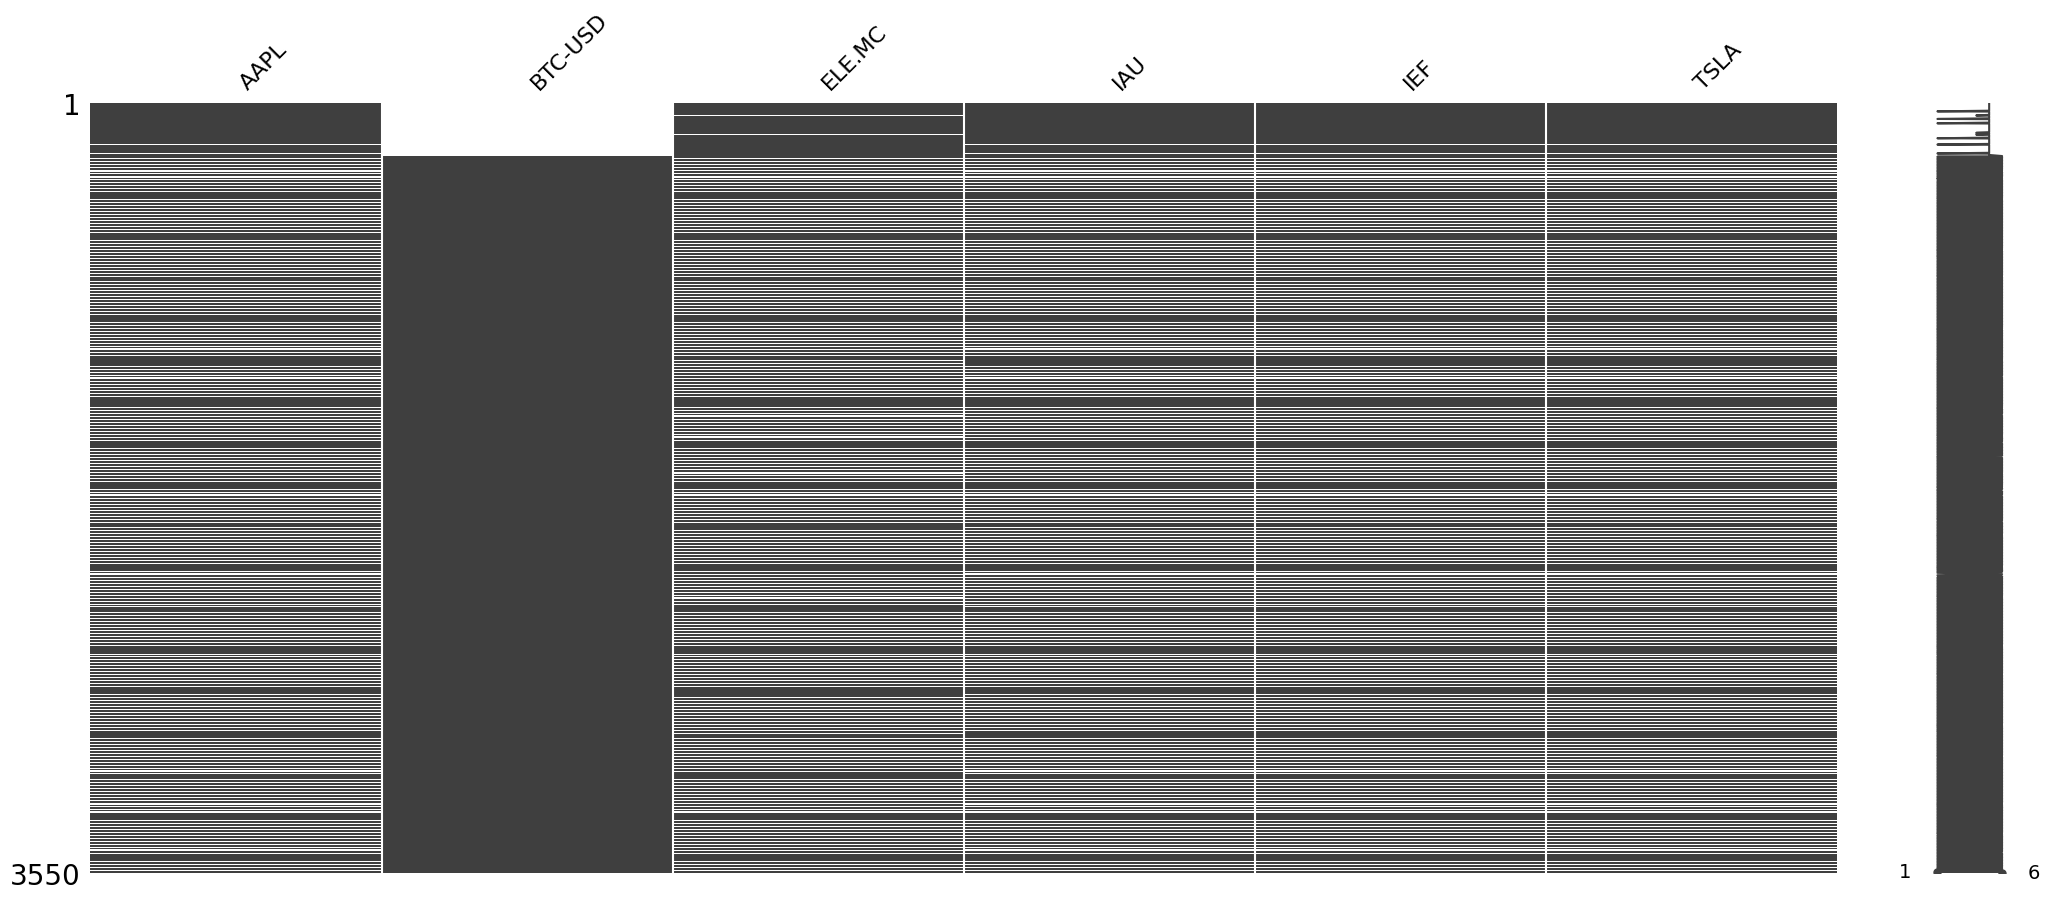

In [ ]:


msno.matrix(data_close_df)

We remove rows containing NaN values, keeping only dates for which all required data are available.

<Axes: >

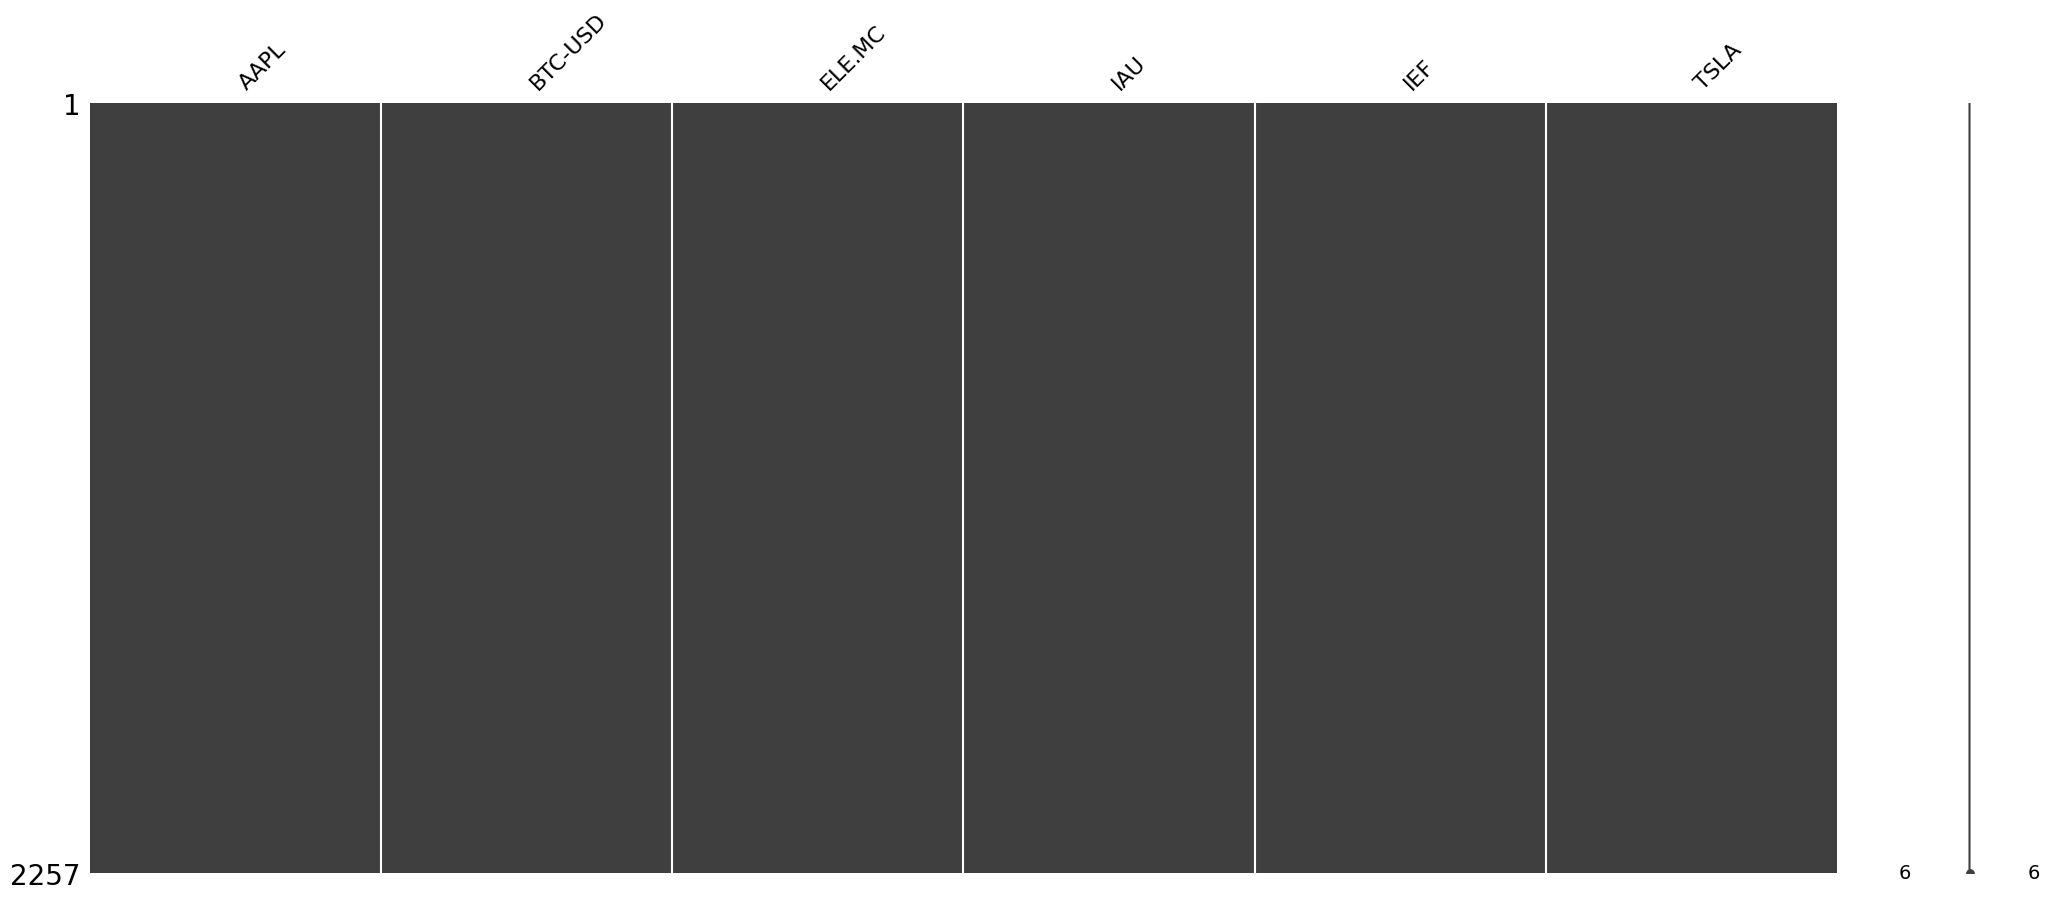

In [ ]:
data_close_df = data_close_df.dropna(axis=0, how="any")
msno.matrix(data_close_df)

We calculate returns.

In [ ]:
ret_close_df = np.log(data_close_df).diff().dropna()

We repeat the same procedure for the other DataFrame.

In [ ]:
data_OHLC_df_corr

Adj Close                                                \
                  AAPL       CSCO         IBM       INTC        MSFT   
Date                                                                   
2013-10-07   15.203010  16.748629  115.038887  17.101440   27.885912   
2013-10-08   14.990749  16.565710  112.959435  16.839266   27.643059   
2013-10-09   15.166852  16.463264  114.602745  16.921661   27.693300   
2013-10-10   15.261921  16.836430  116.783310  17.303694   28.271114   
2013-10-11   15.360729  17.033991  117.661797  17.423548   28.580963   
...                ...        ...         ...        ...         ...   
2023-09-28  170.690002  53.493656  141.580002  35.180000  313.640015   
2023-09-29  171.210007  53.374516  140.300003  35.549999  315.750000   
2023-10-02  173.750000  54.000000  140.800003  35.459999  321.799988   
2023-10-03  172.399994  53.650002  140.389999  35.689999  313.390015   
2023-10-04  173.660004  53.450001  141.070007  35.930000  318.959991   

                             Close                                    ...  \
                  ORCL        AAPL       CSCO         IBM       INTC  ...   
Date                                                                  ...   
2013-10-07   28.221779   17.419643  22.889999  174.005737  22.830000  ...   
2013-10-08   27.817881   17.176430  22.639999  170.860428  22.480000  ...   
2013-10-09   27.663189   17.378214  22.500000  173.346085  22.590000  ...   
2013-10-10   28.350683   17.487143  23.010000  176.644363  23.100000  ...   
2013-10-11   28.582718   17.600357  23.280001  177.973236  23.260000  ...   
...                ...         ...        ...         ...        ...  ...   
2023-09-28  106.150002  170.690002  53.880001  141.580002  35.180000  ...   
2023-09-29  105.919998  171.210007  53.759998  140.300003  35.549999  ...   
2023-10-02  106.709999  173.750000  54.389999  140.800003  35.459999  ...   
2023-10-03  104.519997  172.399994  53.650002  140.389999  35.689999  ...   
2023-10-04  107.080002  173.660004  53.450001  141.070007  35.930000  ...   

                  Open                                        Volume  \
                   IBM       INTC        MSFT        ORCL       AAPL   
Date                                                                   
2013-10-07  173.852768  22.709999   33.599998   32.860001  312292400   
2013-10-08  173.891006  22.870001   33.310001   32.830002  290917200   
2013-10-09  171.481842  22.510000   33.070000   32.450001  301725200   
2013-10-10  175.114716  22.990000   33.310001   32.480000  278602800   
2013-10-11  177.103256  22.830000   33.680000   33.080002  267738800   
...                ...        ...         ...         ...        ...   
2023-09-28  142.139999  34.650002  310.989990  104.029999   56294400   
2023-09-29  142.000000  35.650002  317.750000  107.110001   51814200   
2023-10-02  140.039993  35.610001  316.279999  105.809998   52164500   
2023-10-03  140.869995  35.270000  320.829987  106.419998   49594600   
2023-10-04  140.369995  36.520000  314.029999  104.959999   52963300   

                                                             
                CSCO      IBM      INTC      MSFT      ORCL  
Date                                                         
2013-10-07  29575900  4148854  21321300  35069300  14150100  
2013-10-08  31865700  5834902  36111200  41017600  23780400  
2013-10-09  45438300  4626981  40435400  35878600  19656000  
2013-10-10  38817500  3827209  39189400  42875100  21580700  
2013-10-11  27773800  3381300  24550600  30033300  14018800  
...              ...      ...       ...       ...       ...  
2023-09-28  17204400  5783200  32265300  19683600   7373600  
2023-09-29  13951200  5703600  28758500  24140300   7296100  
2023-10-02  13934000  3275300  26086200  20570000   5963500  
2023-10-03  15700600  3284400  45292600  21033500   8783300  
2023-10-04  17008700  2637600  39829900  20673500   8841700  

[2516 rows x 36 columns]

<Axes: >

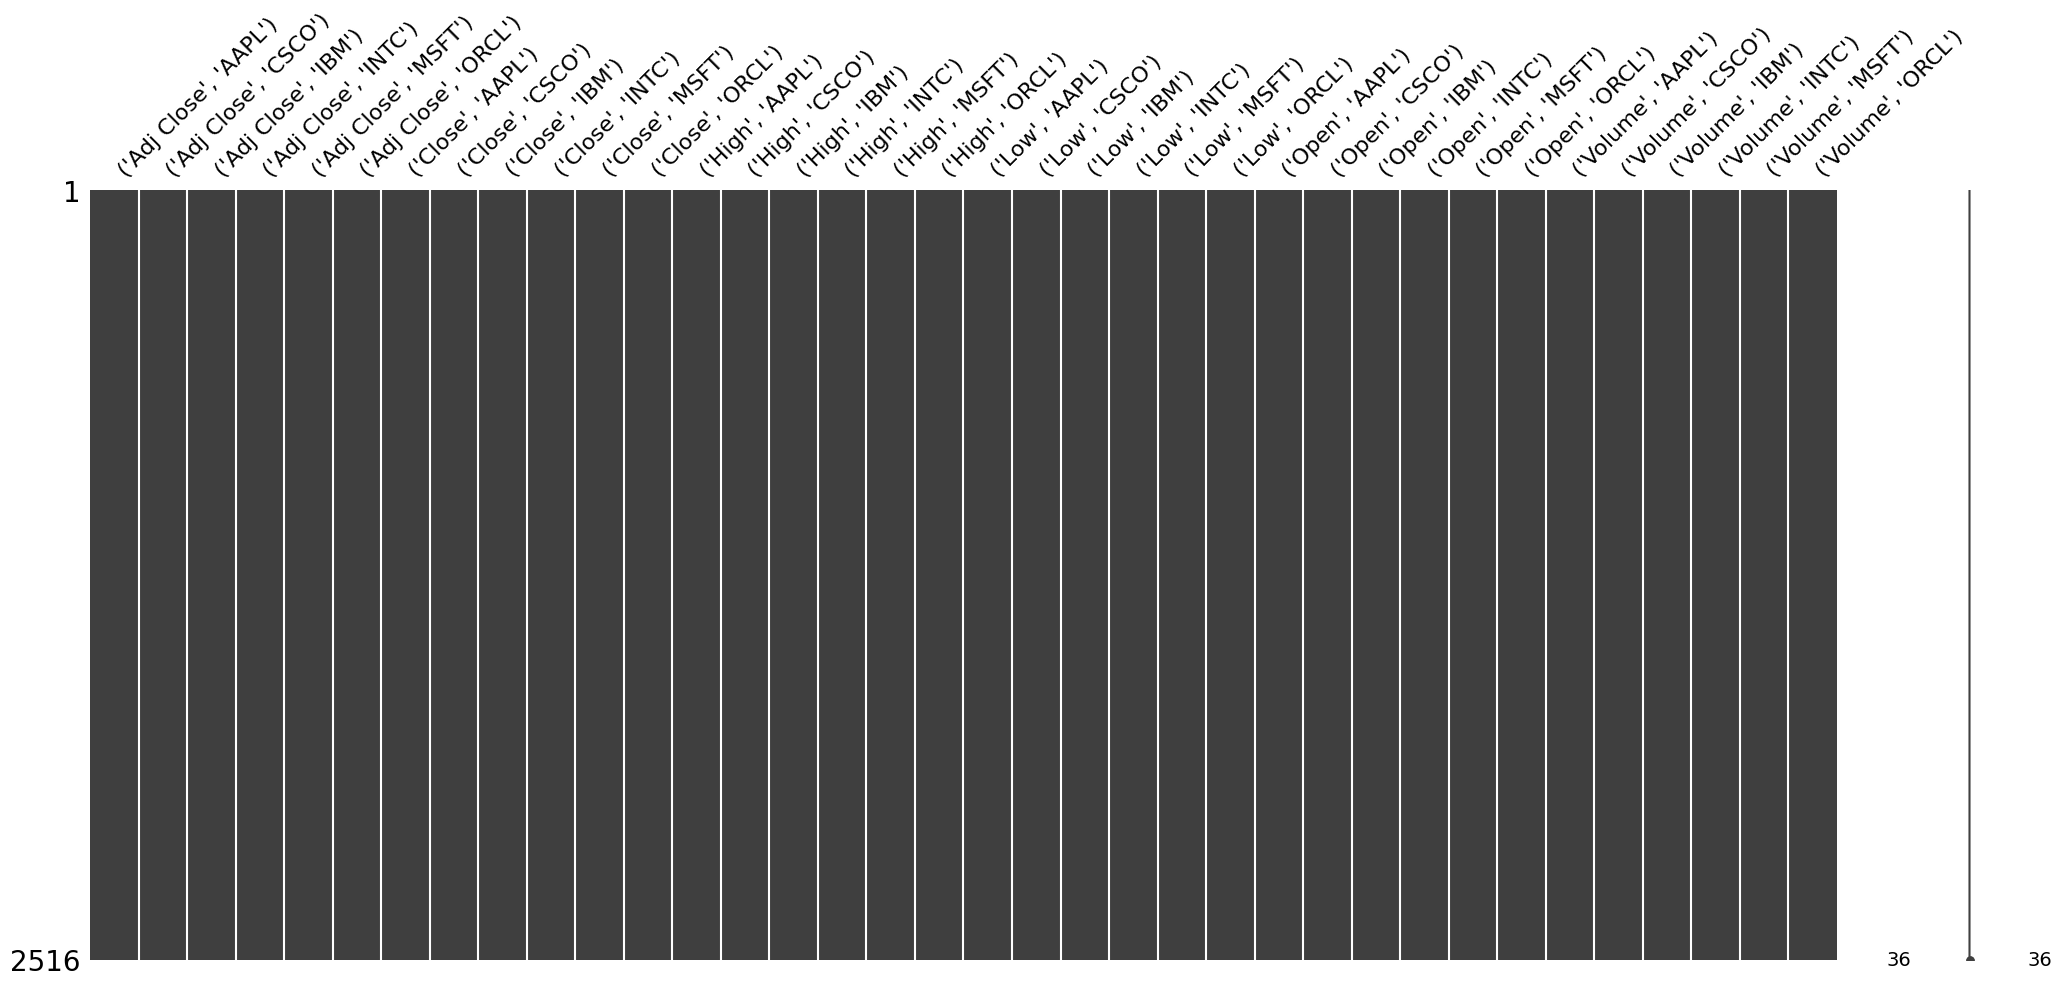

In [ ]:
msno.matrix(data_OHLC_df_corr)

We keep the daily adjusted closing prices and calculate daily returns.

In [ ]:
data_close_df_corr = data_OHLC_df_corr["Adj Close"]
ret_close_df_corr = np.log(data_close_df_corr).diff().dropna()

We create a few charts to compare the return and volatility of each asset.

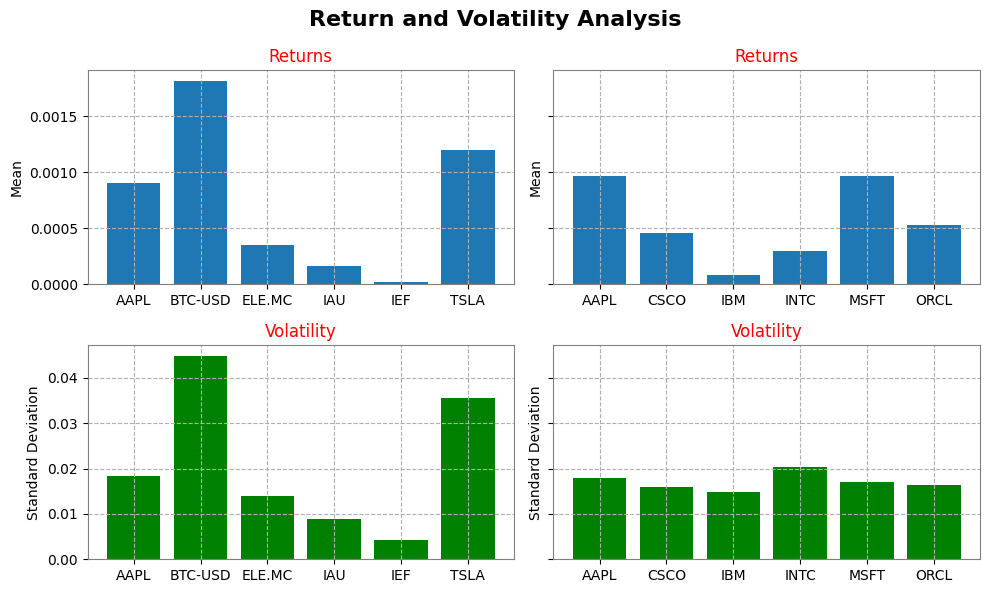

In [ ]:
# Calculate the mean and standard deviation of each column
means = ret_close_df.mean()
stds = ret_close_df.std()
means_corr = ret_close_df_corr.mean()
stds_corr = ret_close_df_corr.std()

# Create a figure with four subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey="row")

# Bar chart of mean returns
axes[0, 0].bar(means.index, means.values)
axes[0, 0].set_ylabel("Mean")
axes[0, 0].set_title("Returns")

# Bar chart of standard deviations
axes[1, 0].bar(stds.index, stds.values, color="green")
axes[1, 0].set_ylabel("Standard Deviation")
axes[1, 0].set_title("Volatility")

# Create a figure with four subplots
axes[0, 1].bar(means_corr.index, means_corr.values)
axes[0, 1].set_ylabel("Mean")
axes[0, 1].set_title("Returns")

# Bar chart of standard deviations
axes[1, 1].bar(stds_corr.index, stds_corr.values, color="green")
axes[1, 1].set_ylabel("Standard Deviation")
axes[1, 1].set_title("Volatility")

# Add an overall title
plt.suptitle("Return and Volatility Analysis", fontsize=16)  # Overall title

# Adjust spacing between subplots
plt.tight_layout()

# Display the figure
plt.show()

We will compare the returns of two assets: `Bitcoin` (BTC-USD) and `US Bonds` (IEF).

In [ ]:
# Create a line chart with Plotly
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=ret_close_df.loc["2016-05-01":, :].index,
        y=ret_close_df.loc["2016-05-01":, :]["BTC-USD"],
        mode="lines",
        name="BTC-USD",
    )
)

fig.add_trace(
    go.Scatter(
        x=ret_close_df.loc["2016-05-01":, :].index,
        y=ret_close_df.loc["2016-05-01":, :]["IEF"],
        mode="lines",
        name="IEF",
    )
)  # iShares 7-10 Year Treasury Bond ETF

# Add titles
fig.update_layout(
    title="HIGH- AND LOW-VOLATILITY ASSET COMPARISON",
    title_font=dict(size=18),  # Set title size
    title_x=0.5,  # Center the title
    yaxis_title="Daily Returns",
    margin=dict(
        l=20, r=20, b=20, t=40
    ),  # Adjust margins
)

We can also compare them using the empirical distributions of daily returns:

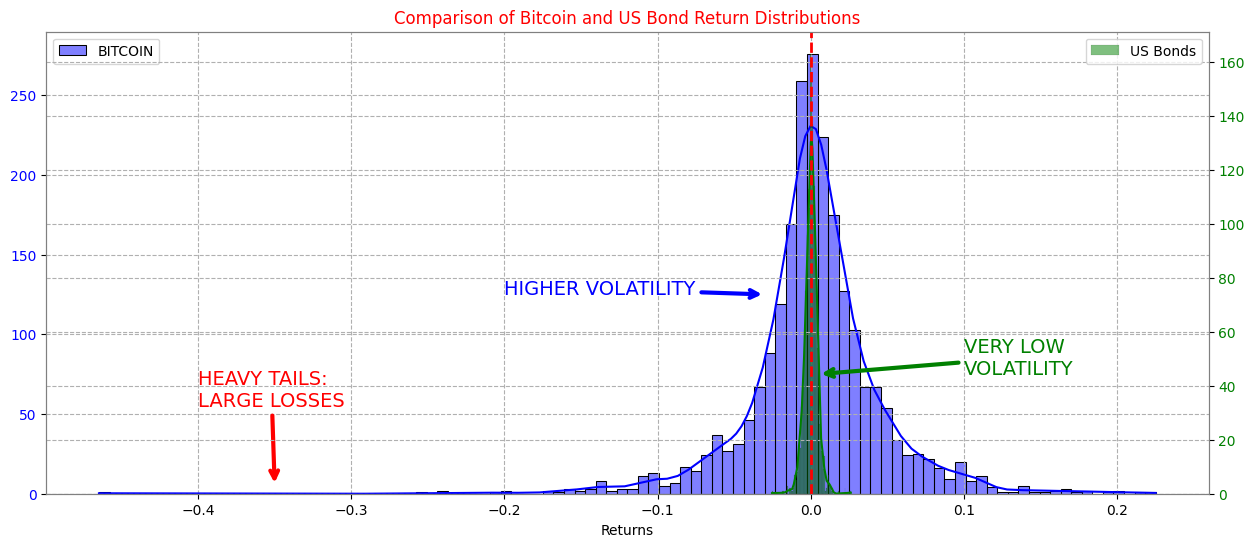

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Create the first histogram
sns.histplot(
    data=ret_close_df,
    x="BTC-USD",
    ax=ax1,
    bins=100,
    color="blue",
    kde=True,
    alpha=0.5,
    label="BITCOIN",
)
ax1.set_xlabel("Returns")
ax1.set_ylabel("", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.legend(loc="upper left")

# # Add annotation text
# text_x = -0.4
# text_y = 25

# ax1.text(-0.2, 125, f"HIGHER VOLATILITY", fontsize=12, color='blue')

ax1.annotate(
    "HIGHER VOLATILITY",
    xy=(-0.03, 125),
    xytext=(-0.2, 125),
    arrowprops=dict(arrowstyle="->", linewidth=3, color="blue"),
    fontsize=14,
    color="blue",
)

ax1.annotate(
    "VERY LOW\nVOLATILITY",
    xy=(0.005, 75),
    xytext=(0.1, 75),
    arrowprops=dict(arrowstyle="->", linewidth=3, color="green"),
    fontsize=14,
    color="green",
)

ax1.annotate(
    "HEAVY TAILS:\nLARGE LOSSES",
    xy=(-0.35, 5),
    xytext=(-0.4, 55),
    arrowprops=dict(arrowstyle="->", linewidth=3, color="red"),
    fontsize=14,
    color="RED",
)


# Create a second y-axis
ax2 = ax1.twinx()

# Create the second histogram
sns.histplot(
    data=ret_close_df,
    x="IEF",
    ax=ax2,
    bins=100,
    color="green",
    kde=True,
    alpha=0.5,
    label="US Bonds",
)
ax2.set_ylabel("", color="green")
ax2.tick_params(axis="y", labelcolor="green")
ax2.legend(loc="upper right")

# Add a vertical line at zero
plt.axvline(x=0, color="red", linestyle="--", linewidth=2)
# Set title and display the chart
plt.title("Comparison of Bitcoin and US Bond Return Distributions")
plt.show()

In [ ]:
print("BITCOIN:")
print("  MEAN:", np.around(ret_close_df["BTC-USD"].mean() * 252, decimals=3))
print("  STD:", np.around(ret_close_df["BTC-USD"].std() * np.sqrt(252), decimals=3))
print()
print("US BONDS:")
print("  MEAN:", np.around(ret_close_df["IEF"].mean() * 252, decimals=3))
print("  STD:", np.around(ret_close_df["IEF"].std() * np.sqrt(252), decimals=3))

BITCOIN:
  MEAN: 0.459
  STD: 0.713

US BONDS:
  MEAN: 0.004
  STD: 0.066


---

#### Exercise

Load the data from `../data/datos_ejercicio_asimetria.csv` and complete the following tasks using the two assets provided:

1. Plot the returns of each asset. What do you observe?
2. Analyze the return-risk trade-off. Which asset appears more attractive based only on mean return and variance? Explain briefly.

Reading the file from GitHub (use this option in Colab)

In [ ]:
file_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python-2023/main/Tema_1_Activos_Intro/data/datos_ejercicio_asimetria.csv"
datos_activo = pd.read_csv(file_path, index_col=0, parse_dates=True)
datos_activo

,Activo,BTC-USD
Date,,
2014-09-18,-0.023950,-0.074643
2014-09-19,0.003392,-0.072402
2014-09-22,0.028220,0.018461
2014-09-23,0.043569,0.080333
2014-09-24,0.016959,-0.029306
...,...,...
2023-09-28,-0.037223,0.025063
2023-09-29,-0.056761,-0.004073
2023-10-02,-0.071284,0.022743


Reading the local file

In [ ]:
# datos_activo = pd.read_csv(
#     "../data/datos_ejercicio_asimetria.csv", index_col=0, parse_dates=True
# )


# datos_activo

In [ ]:
# TO-DO: Add your calculations and explanations here

---

## 1.4 Skewness and Kurtosis

### Skewness

The third standardized moment of a distribution measures its asymmetry:

* **Positive skewness** indicates a longer or heavier right tail.
* **Negative skewness** indicates a longer or heavier left tail.
* **Zero skewness** indicates a symmetric distribution.

<center>
    <img src="https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/Finance_Technology/Tema_1_Activos_Intro/imgs/skewness.PNG"  alt="drawing" width="500">
</center>

Let's analyze the skewness of our asset returns. If returns followed a normal distribution, skewness would be 0.

In [ ]:
df_skew = ret_close_df.skew()
df_corr_skew = ret_close_df_corr.skew()

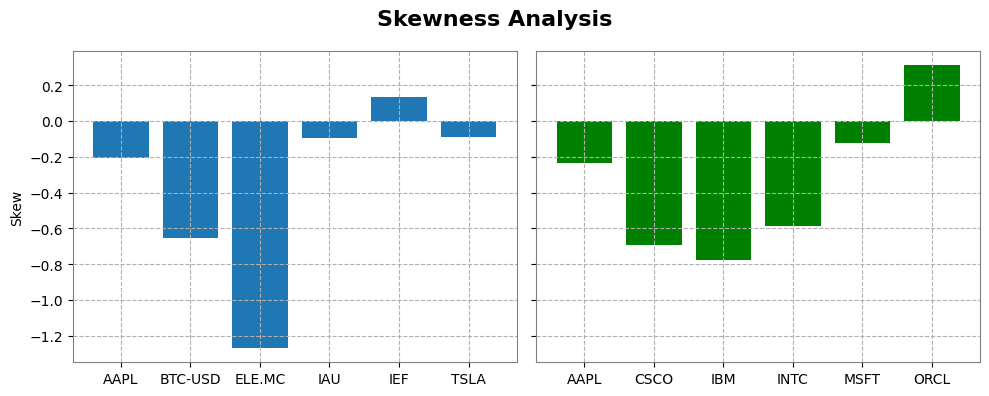

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey="row")

# Plot skewness for the first group
axes[0].bar(df_skew.index.values, df_skew.values)
axes[0].set_ylabel("Skew")
axes[0].set_title("")

# Plot skewness for the second group
axes[1].bar(df_corr_skew.index.values, df_corr_skew.values, color="green")
axes[1].set_ylabel("")
axes[1].set_title("")


# Add an overall title
plt.suptitle("Skewness Analysis", fontsize=16)  # Overall title

# Adjust spacing between subplots
plt.tight_layout()

# Display the figure
plt.show()

Most of the assets in this example display negative skewness. This means that the left tail is generally heavier than the right tail, implying relatively greater exposure to extreme negative returns than to extreme positive returns.

### Quick Practice 4 — Interpreting Skewness

Using `df_skew`:

1. Identify the asset with the most negative skewness.
2. Identify the asset with the most positive skewness.
3. Plot the return distributions of those two assets.

**Question:** Which asset appears to have greater downside-tail asymmetry?

In [ ]:
# Write your code here


Let's examine `Endesa` (ELE.MC), which has strongly negative skewness:

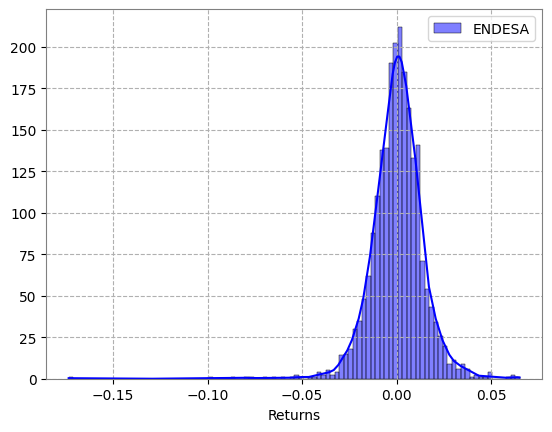

In [ ]:
sns.histplot(
    data=ret_close_df,
    x="ELE.MC",
    bins=100,
    color="blue",
    kde=True,
    alpha=0.5,
    label="ENDESA",
)


plt.xlabel("Returns")


plt.ylabel("", color="blue")


plt.legend()


plt.show()

In [ ]:
print("Endesa skewness:", np.around(ret_close_df["ELE.MC"].skew(), decimals=3))

Endesa skewness: -1.27


Let's examine `Oracle` (ORCL), which has strongly positive skewness:

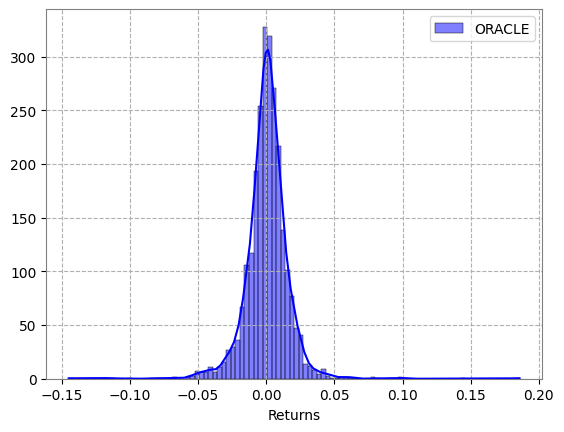

In [ ]:
sns.histplot(
    data=ret_close_df_corr,
    x="ORCL",
    bins=100,
    color="blue",
    kde=True,
    alpha=0.5,
    label="ORACLE",
)


plt.xlabel("Returns")


plt.ylabel("", color="blue")


plt.legend()


plt.show()

In [ ]:
print(f"Oracle skewness: {ret_close_df_corr['ORCL'].skew():.3f}")

Oracle skewness: 0.312


Let's examine `Tesla` (TSLA), which has approximately neutral skewness:

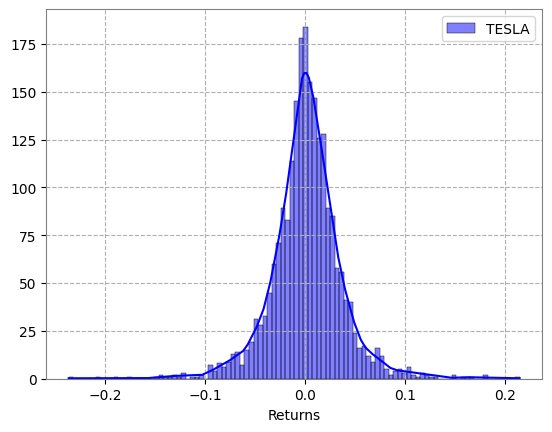

In [ ]:
sns.histplot(
    data=ret_close_df,
    x="TSLA",
    bins=100,
    color="blue",
    kde=True,
    alpha=0.5,
    label="TESLA",
)


plt.xlabel("Returns")


plt.ylabel("", color="blue")


plt.legend()


plt.show()

In [ ]:
print("Tesla skewness:", np.around(ret_close_df["TSLA"].skew(), decimals=3))

Tesla skewness: -0.087


<hr>

### Kurtosis

Kurtosis is a statistical measure related to the shape of a distribution, especially the weight of its tails relative to a normal distribution.

An intuitive way to think about it is to compare distributions that place different amounts of probability near the center and in the tails:

- **Low kurtosis (platykurtic)**: the distribution has relatively light tails, so extreme observations are less frequent.
- **High kurtosis (leptokurtic)**: the distribution has heavier tails, so extreme observations are more frequent.
- **Normal kurtosis (mesokurtic)**: the normal distribution provides the benchmark.

In short, kurtosis helps us assess whether extreme observations are more or less common than under a normal distribution. The key idea is the **weight of the tails**, not simply how peaked the center of the distribution appears.

Using the excess-kurtosis convention employed by Pandas, the interpretation is:

* **Kurtosis equal to 0** corresponds to the normal-distribution benchmark.
* **Kurtosis greater than 0** indicates heavier tails and a higher frequency of extreme returns.
* **Kurtosis less than 0** indicates lighter tails and a lower frequency of extreme returns relative to the normal benchmark.

In [ ]:
df_curto = ret_close_df.kurtosis()
df_corr_curto = ret_close_df_corr.kurtosis()

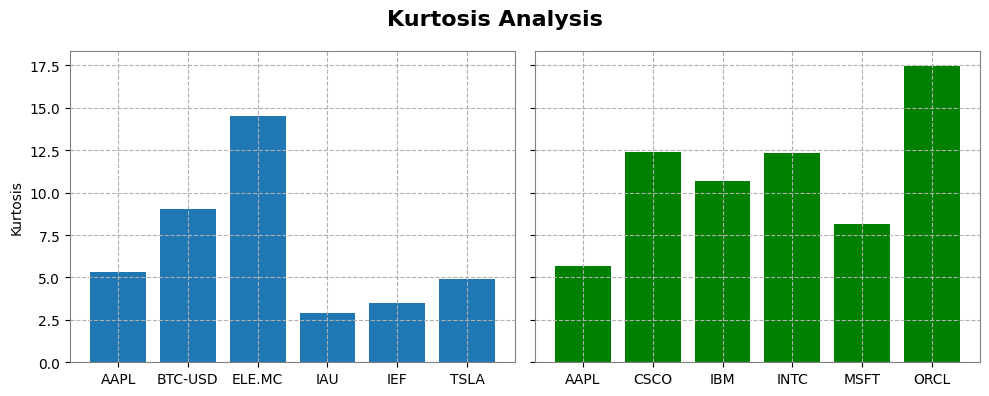

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey="row")
axes[0].bar(df_curto.index.values, df_curto.values)
axes[0].set_ylabel("Kurtosis")
axes[0].set_title("")
axes[1].bar(df_corr_curto.index.values, df_corr_curto.values, color="green")
axes[1].set_ylabel("")
axes[1].set_title("")

plt.suptitle("Kurtosis Analysis", fontsize=16)  # Overall title
plt.tight_layout()
plt.show()

Let's examine the impact of kurtosis on return distributions.

Remember that high kurtosis indicates a greater frequency of extreme returns, which can include very large losses.

We will plot the return distribution of one asset with high kurtosis and another with lower kurtosis.

### Quick Practice 5 — Kurtosis

Using `df_curto`:

1. Find the asset with the highest kurtosis.
2. Find the asset with the lowest kurtosis.
3. Compare their return histograms.

**Question:** Which distribution appears to have heavier tails?

In [ ]:
# Write your code here


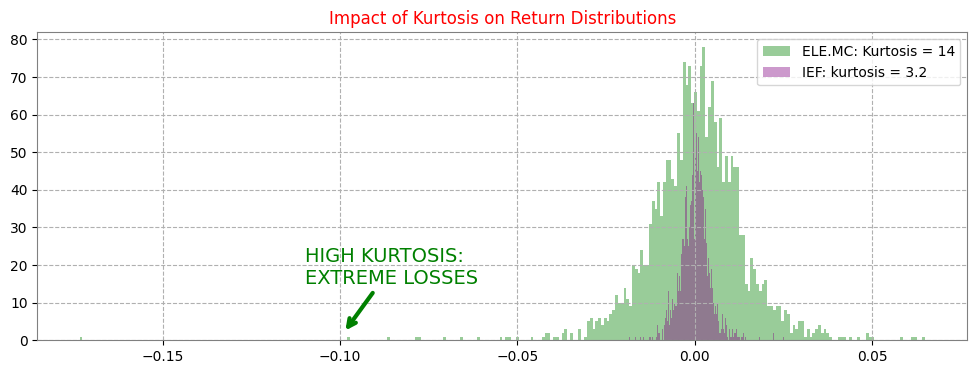

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

plt.hist(
    ret_close_df["ELE.MC"],
    bins=300,
    color="green",
    alpha=0.4,
    label="ELE.MC: Kurtosis = 14",
)
# plt.hist(ret_close_df_corr['ORCL'], bins=300, color='green', alpha=0.4, label='ORCL')
plt.hist(
    ret_close_df["IEF"],
    bins=300,
    color="purple",
    alpha=0.4,
    label="IEF: kurtosis = 3.2",
)

# Add an annotation arrow
ax.annotate(
    "HIGH KURTOSIS:\nEXTREME LOSSES",
    xy=(-0.099, 2),
    xytext=(-0.11, 15),
    arrowprops=dict(arrowstyle="->", linewidth=3, color="green"),
    fontsize=14,
    color="green",
)

plt.title("Impact of Kurtosis on Return Distributions")
plt.legend()
plt.show()

## 1.5 Student's t Distribution for Returns

The Student's t distribution is another probability distribution often used to model asset returns. Its main characteristics are:

* It is symmetric and bell-shaped, like the normal distribution.
* It has **heavier tails** than the normal distribution, meaning that extreme events have higher probability.
* It has an additional parameter called the **degrees of freedom**. As the degrees of freedom increase, the Student's t distribution approaches the normal distribution.

The **degrees of freedom** are a key parameter determining the shape of a Student's t distribution.

The Student's t distribution is commonly introduced when estimating a population mean from a small sample and the population standard deviation is unknown. Lower degrees of freedom produce a wider distribution with heavier tails; as the degrees of freedom increase, the distribution gradually approaches the normal distribution.

**Effect of the degrees of freedom:**

- **Low degrees of freedom:** heavier tails and a higher probability of extreme observations.
- **High degrees of freedom:** the distribution becomes increasingly similar to the normal distribution.

Let's see how a Student's t distribution changes as we vary the degrees of freedom:

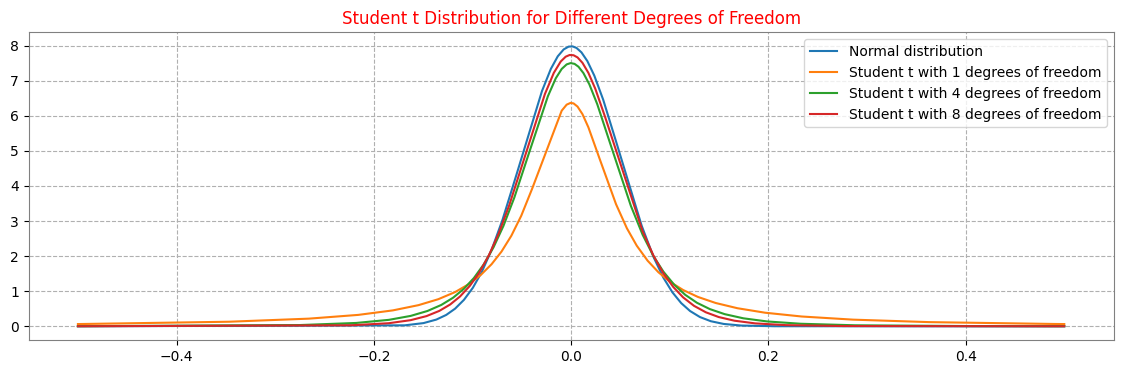

In [ ]:
mu_btc = 0.0
sigma_btc = 0.05

xmin = -0.5
xmax = 0.5
x = np.linspace(xmin, xmax, 1000)
n_pdf = stats.norm.pdf(x, mu_btc, sigma_btc)

plt.figure(figsize=(14, 4))

plt.plot(x, n_pdf, label="Normal distribution")

for libertad_grad in [1, 4, 8]:
    t_params = (
        libertad_grad,
        mu_btc,
        sigma_btc,
    )  # Student's t distribution parameters
    t_pdf = stats.t.pdf(x, *t_params)

    # Plot the Student's t density
    plt.plot(x, t_pdf, label=f"Student t with {libertad_grad} degrees of freedom")

plt.title("Student t Distribution for Different Degrees of Freedom")
plt.legend()
plt.show()

## 1.6 Conclusions

1. We learned how to calculate asset returns, which we will use for descriptive analysis instead of raw prices.

2. We introduced the return-risk framework, where expected return is summarized by the mean and risk by the standard deviation.

3. We examined the normal-distribution assumption and saw that financial returns frequently depart from normality.

4. In particular, financial returns often display heavy tails, which increases the frequency of extreme outcomes relative to a normal distribution.

5. We estimated skewness and kurtosis to describe asymmetry and tail behavior.

6. We introduced the Student's t distribution as an alternative model that can accommodate heavier tails than the normal distribution.

## S&P 500 Tail Risk Challenge




You are a risk analyst at an investment fund. Your team uses a normal distribution as a baseline model for daily stock returns. The risk manager asks you to identify a stock whose historical returns combine **high excess kurtosis and strongly negative skewness.**

This combination deserves attention: high kurtosis highlights the influence of extreme observations, while negative skewness indicates asymmetry towards losses. Together, they may raise concerns about risk estimates based on a normal distribution.

Your mission

Find the eligible S&P 500 stock with **the highest combined tail-risk score**. Use **daily Adjusted Close prices**, adjusted for stock splits and dividends, **from 2 January 2024 to 31 December 2025**, inclusive, to analyse each stock’s daily returns.

The score gives equal weight to:

**High excess kurtosis**: higher values receive a better ranking.
**Negative skewness**: more negative values receive a better ranking.

Each measure is converted into a percentile rank among eligible stocks, with equal values receiving the same average rank. The combined score is:

$$C_i=0.5\,P(K_i)+0.5\,P(-S_i)$$

where $K_i$ is sample excess kurtosis, $S_i$ is sample skewness, and $P$ is the percentile rank. Both statistics use finite-sample bias corrections.

The objective is to maximise this combined score. The winning stock need not have the highest kurtosis or the most negative skewness individually.

**Competition schedule**

**Opens:** Thursday, 8 October 2026, at 14:00.

**Closes:** Monday, 12 October 2026, at 23:59.

**Eligible assets**

The stock universe consists of the tickers in the **“S&P 500 component stocks”** table on Wikipedia, using the snapshot taken before the competition opens. Subsequent changes to the [Wikipedia](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies) list will not affect the competition.

A stock is eligible only if:

Its sample skewness is **strictly negative**.
It has valid daily returns for **at least 90% of the US equity trading sessions** in the analysis period.
Its skewness and kurtosis are finite and defined.

Weekends and market holidays do not count as trading sessions. All submissions are evaluated using the instructor’s fixed reference dataset.

**Attempts and submissions**

You have **5 attempts**. Analyse your candidates carefully before submitting.

Enter **only the exact ticker shown in Wikipedia’s component table**, in uppercase and preserving punctuation. Do not enter company names, explanations or multiple tickers. If your data provider uses a different ticker format, use the Wikipedia format for your submission.

Every submitted attempt counts, including repeated, unrecognised or ineligible tickers. Select **“Submit all and finish”** to confirm your answer.

**Feedback and scoring**

For each eligible ticker, Moodle will display:

Its reference excess kurtosis and skewness.
Its combined score.
Its distance from the highest combined score.
Your grade out of 10.

Grades are calculated relative to the best combined score, with the optimal asset receiving **10/10**, and mapped to Moodle’s supported grading percentages. Unrecognised or ineligible tickers receive **0/10**.

Your **highest grade** across all attempts will be retained. You can check your previous attempts on the questionnaire’s main page.

**Think like a risk analyst**

The challenge identifies a historical distributional profile that warrants closer examination. The combined score is an educational screening rule, not a direct measure of potential losses, an investment recommendation or a prediction of future performance.

Code for extracting SP500 components


In [ ]:
import pandas as pd
import requests
from io import StringIO

# Download the S&P 500 table from Wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

# Extract the ticker symbols
sp500_tickers = pd.read_html(StringIO(html))[0]["Symbol"].tolist()

# Adapt tickers to Yahoo Finance format (e.g. BRK.B -> BRK-B)
sp500_tickers = [ticker.replace(".", "-") for ticker in sp500_tickers]

sp500_tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BE',
 'BNY',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'COP',
 'E